In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import pandas as pd


In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize & reshape
X_train = X_train.reshape(-1, 784) / 255.0
X_test = X_test.reshape(-1, 784) / 255.0

# One-hot encode
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

print("Dataset Loaded Successfully")


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Dataset Loaded Successfully


In [ ]:
def baseline_model():
    model = models.Sequential([
        layers.Dense(128, activation='relu', input_shape=(784,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

baseline = baseline_model()
history_base = baseline.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=128
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8291 - loss: 0.6054 - val_accuracy: 0.9462 - val_loss: 0.1832
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9596 - loss: 0.1388 - val_accuracy: 0.9668 - val_loss: 0.1079
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9740 - loss: 0.0918 - val_accuracy: 0.9723 - val_loss: 0.0887
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9792 - loss: 0.0695 - val_accuracy: 0.9732 - val_loss: 0.0847
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9837 - loss: 0.0522 - val_accuracy: 0.9748 - val_loss: 0.0784
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9867 - loss: 0.0428 - val_accuracy: 0.9756 - val_loss: 0.0832
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9893 - loss: 0.0345 - val_accuracy: 0.9793 - val_loss: 0.0742
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9912 - loss: 0.0293 - val_accuracy: 0.

In [ ]:
def dropout_model():
    model = models.Sequential([
        layers.Dense(128, activation='relu', input_shape=(784,)),
        layers.Dropout(0.5),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

dropout = dropout_model()
history_dropout = dropout.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=128
)


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6262 - loss: 1.1335 - val_accuracy: 0.9333 - val_loss: 0.2273
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8881 - loss: 0.3902 - val_accuracy: 0.9506 - val_loss: 0.1670
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9146 - loss: 0.3066 - val_accuracy: 0.9576 - val_loss: 0.1444
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9253 - loss: 0.2681 - val_accuracy: 0.9609 - val_loss: 0.1314
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9339 - loss: 0.2333 - val_accuracy: 0.9641 - val_loss: 0.1232
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9391 - loss: 0.2210 - val_accuracy: 0.9652 - val_loss: 0.1182
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9410 - loss: 0.2148 - val_accuracy: 0.9676 - val_loss: 0.1104
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9450 - loss: 0.1971 - val_accuracy: 0

In [ ]:
def l2_model():
    model = models.Sequential([
        layers.Dense(128, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001),
                     input_shape=(784,)),
        layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001)),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

l2 = l2_model()
history_l2 = l2.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=128
)


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8288 - loss: 0.8472 - val_accuracy: 0.9340 - val_loss: 0.3711
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9502 - loss: 0.3262 - val_accuracy: 0.9626 - val_loss: 0.2652
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9634 - loss: 0.2538 - val_accuracy: 0.9670 - val_loss: 0.2334
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9695 - loss: 0.2227 - val_accuracy: 0.9687 - val_loss: 0.2140
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9724 - loss: 0.2025 - val_accuracy: 0.9725 - val_loss: 0.1971
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9740 - loss: 0.1893 - val_accuracy: 0.9749 - val_loss: 0.1841
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9763 - loss: 0.1781 - val_accuracy: 0.9716 - val_loss: 0.1838
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9778 - loss: 0.1692 - val_accuracy: 0.

In [ ]:
def batchnorm_model():
    model = models.Sequential([
        layers.Dense(128, input_shape=(784,)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dense(64),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

batchnorm = batchnorm_model()
history_bn = batchnorm.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=128
)


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8427 - loss: 0.5653 - val_accuracy: 0.9595 - val_loss: 0.1319
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9689 - loss: 0.1118 - val_accuracy: 0.9662 - val_loss: 0.1071
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9796 - loss: 0.0686 - val_accuracy: 0.9730 - val_loss: 0.0851
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9857 - loss: 0.0498 - val_accuracy: 0.9690 - val_loss: 0.0976
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9895 - loss: 0.0361 - val_accuracy: 0.9772 - val_loss: 0.0764
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9908 - loss: 0.0300 - val_accuracy: 0.9762 - val_loss: 0.0756
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9931 - loss: 0.0233 - val_accuracy: 0.9768 - val_loss: 0.0832
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9932 - loss: 0.0216 - val_accuracy: 0.

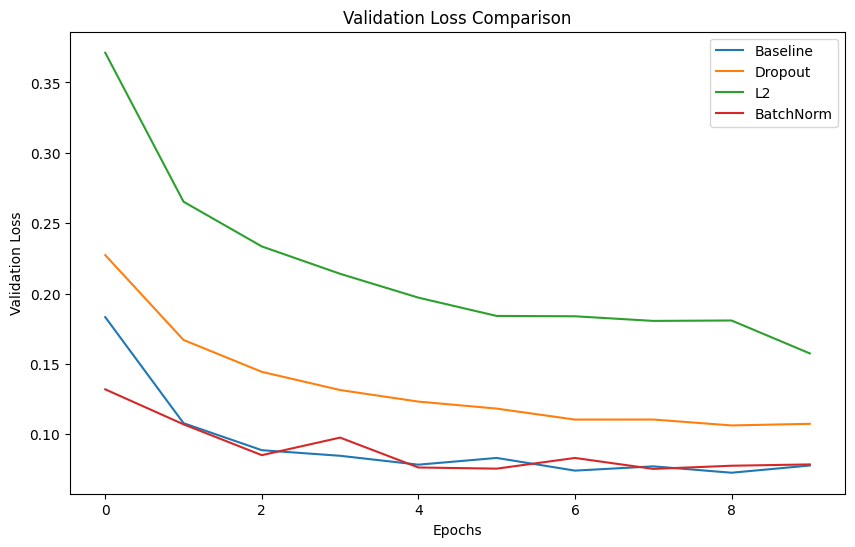

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(history_base.history['val_loss'], label='Baseline')
plt.plot(history_dropout.history['val_loss'], label='Dropout')
plt.plot(history_l2.history['val_loss'], label='L2')
plt.plot(history_bn.history['val_loss'], label='BatchNorm')

plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison")
plt.legend()
plt.show()


In [ ]:


data = {
    "Model": ["Baseline", "Dropout", "L2 Regularization", "Batch Normalization"],
    "Validation Accuracy": [
        history_base.history['val_accuracy'][-1],
        history_dropout.history['val_accuracy'][-1],
        history_l2.history['val_accuracy'][-1],
        history_bn.history['val_accuracy'][-1]
    ]
}

df = pd.DataFrame(data)
df


,Model,Validation Accuracy
0,Baseline,0.9786
1,Dropout,0.9679
2,L2 Regularization,0.9770
3,Batch Normalization,0.9783


In [ ]:
print("Conclusion:")
print("Regularization techniques like Dropout, L2 Regularization, and Batch Normalization reduce overfitting.")
print("Batch Normalization shows best generalization and training stability.")


Conclusion:
Regularization techniques like Dropout, L2 Regularization, and Batch Normalization reduce overfitting.
Batch Normalization shows best generalization and training stability.
